## Problem Statement

Financial institutions receive thousands of loan applications and must determine whether an applicant is eligible for loan approval based on factors such as income, credit history, employment status, education level, and demographic information. Manual loan approval processes can be time-consuming, inconsistent, and prone to human bias, making automated decision-support systems increasingly important.

The objective of this project is to perform exploratory data analysis (EDA) on a loan status dataset to uncover patterns, trends, and relationships between applicant characteristics and loan approval outcomes. Insights obtained from the analysis will support the development of a machine learning classification model capable of predicting whether a loan application is likely to be approved or rejected.

The analysis will focus on:

Understanding the structure and quality of the dataset
Identifying missing values, outliers, and inconsistencies
Exploring distributions of numerical and categorical variables
Examining relationships between applicant features and loan approval status
Discovering important factors influencing loan approval decisions
Preparing the dataset for preprocessing and machine learning modeling

Ultimately, the project aims to build a reliable predictive system that can assist financial institutions in improving loan approval efficiency, reducing risk, and making more data-driven lending decisions.

## Dataset Description

The dataset contains information about loan applicants and their loan approval status. Each row represents a loan application and includes demographic, financial, employment, and credit-related information.

The target variable in the dataset is `Loan_Status`, which indicates whether a loan application was approved or rejected.

### Dataset Features

| Feature | Description | Data Type |
|---|---|---|
| `Loan_ID` | Unique loan application ID | Categorical |
| `Gender` | Gender of the applicant | Categorical |
| `Married` | Marital status of the applicant | Categorical |
| `Dependents` | Number of dependents | Ordinal Categorical |
| `Education` | Education level of the applicant | Categorical |
| `Self_Employed` | Self-employment status | Categorical |
| `ApplicantIncome` | Income of the applicant | Numerical |
| `CoapplicantIncome` | Income of the co-applicant | Numerical |
| `LoanAmount` | Requested loan amount | Numerical |
| `Loan_Amount_Term` | Loan repayment term | Numerical |
| `Credit_History` | Applicant credit history | Binary |
| `Property_Area` | Property area category | Categorical |
| `Loan_Status` | Loan approval status | Target Variable |

### Domain Values of Categorical Variables

| Variable | Possible Values |
|---|---|
| `Gender` | `Female`, `Male` |
| `Married` | `Yes`, `No` |
| `Dependents` | `0`, `1`, `2`, `3+` |
| `Education` | `Graduate`, `Not Graduate` |
| `Self_Employed` | `Yes`, `No` |
| `Credit_History` | `0.0`, `1.0` |
| `Property_Area` | `Rural`, `Semiurban`, `Urban` |
| `Loan_Status` | `Y`, `N` |

### Target Variable

| Variable | Meaning |
|---|---|
| `Loan_Status = Y` | Loan Approved |
| `Loan_Status = N` | Loan Rejected |

This is a binary classification problem where the goal is to predict whether a loan application will be approved or rejected.

## Evaluation Metric Selection

This project involves predicting whether a loan application will be approved or rejected, making it a binary classification problem. In classification tasks, selecting an appropriate evaluation metric is important because different types of prediction errors may have different business impacts.

In the context of loan approval prediction:

- Approving a loan for a high-risk applicant may lead to financial losses for the institution.
- Rejecting a qualified applicant may result in a lost business opportunity and reduced customer satisfaction.

Since both false positives and false negatives are important, relying solely on accuracy may not provide a complete measure of model performance, especially if the dataset is imbalanced.

For this reason, the primary evaluation metric for this project will be the **F1-score**, as it provides a balance between precision and recall.

Where:

- **Precision** measures how many predicted approved loans were actually correct.
- **Recall** measures how many actual approved loans were correctly identified.

Using the F1-score helps ensure that the model maintains a balance between minimizing risky loan approvals and correctly identifying eligible applicants.

In addition to the F1-score, the following evaluation metrics will also be used to comprehensively assess model performance:

- Accuracy
- Precision
- Recall
- ROC-AUC Score
- Confusion Matrix

## Load packages

In [ ]:
import os
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



## Load dataset

In [ ]:
data = pd.read_csv("data/raw/loan_status.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Inspect and clean dataset

In [3]:
# copy dataset
df = data.copy()

In [4]:
# check dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 614
Columns: 13


In [5]:
# check column names
list(df.columns)

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [6]:
# rename columns to maintain consistency
df.columns = df.columns.str.replace("_", "")
list(df.columns)

['LoanID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'SelfEmployed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'LoanAmountTerm',
 'CreditHistory',
 'PropertyArea',
 'LoanStatus']

In [7]:
# inspect data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoanID             614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   SelfEmployed       582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   LoanAmountTerm     600 non-null    float64
 10  CreditHistory      564 non-null    float64
 11  PropertyArea       614 non-null    object 
 12  LoanStatus         614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
# take a look at the dataset and ensure variables of the right data types
df.head(5)

,LoanID,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# Cast CreditHistory to appropriate type
df["CreditHistory"] = df["CreditHistory"].astype("category")


In [10]:
# we could model this as categorical variables but that would restrict having intermediate values
# and limit the domain of values this can take, leaving it as numerical variable
df["LoanAmountTerm"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [11]:
# top 10 Categorical variables domains
for col in df.select_dtypes(include=["object", "category"]).columns:
    print(col)
    print(df[col].unique()[:10])
    print("-" * 40)


LoanID
['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020']
----------------------------------------
Gender
['Male' 'Female' nan]
----------------------------------------
Married
['No' 'Yes' nan]
----------------------------------------
Dependents
['0' '1' '2' '3+' nan]
----------------------------------------
Education
['Graduate' 'Not Graduate']
----------------------------------------
SelfEmployed
['No' 'Yes' nan]
----------------------------------------
CreditHistory
[1.0, 0.0, NaN]
Categories (2, float64): [0.0, 1.0]
----------------------------------------
PropertyArea
['Urban' 'Rural' 'Semiurban']
----------------------------------------
LoanStatus
['Y' 'N']
----------------------------------------


In [12]:
# Remove Irrelevant Features, some columns may not contribute to prediction.
# Example: LoanID is only an identifier with no predictive meaning

df = df.drop(columns=["LoanID"])
df.head(3)


,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [13]:
# standardize categorical variables
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].str.title()

df.head(3)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [14]:
# map LoanStatus column to yes and no
df["LoanStatus"] = df["LoanStatus"].map(lambda value: "Yes" if value=="Y" else "No")
df.head(3)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Yes
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes


In [15]:
# check for duplicates
df.duplicated().sum()

0

In [16]:
# Generate statistical summary (Numerical)
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


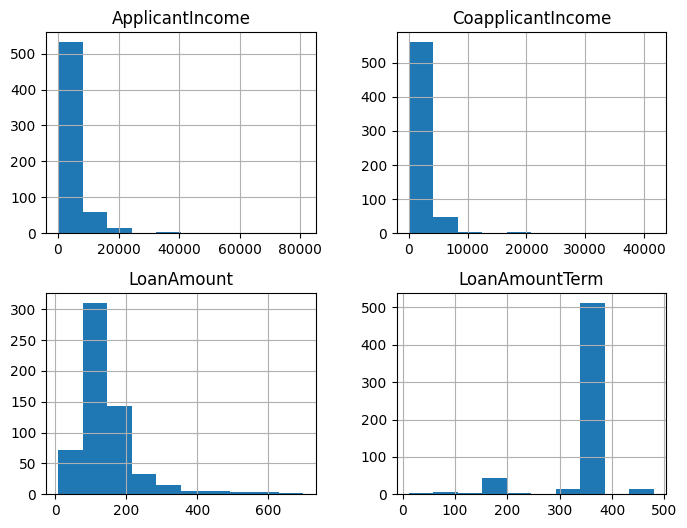

In [17]:
# numerical data distribution
axes = df.hist(bins=10, figsize=(8, 6))

In [18]:
# Generate statistical summary (categorical variables)
df.describe(include=["object", "category"])

,Gender,Married,Dependents,Education,SelfEmployed,CreditHistory,PropertyArea,LoanStatus
count,601,611,599,614,582,564.0,614,614
unique,2,2,4,2,2,2.0,3,2
top,Male,Yes,0,Graduate,No,1.0,Semiurban,Yes
freq,489,398,345,480,500,475.0,233,422


In [19]:
# missing values
df.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
SelfEmployed         32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
LoanAmountTerm       14
CreditHistory        50
PropertyArea          0
LoanStatus            0
dtype: int64

In [20]:
# percentage of missing data
(df.isnull().sum() / len(df)) * 100

Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
SelfEmployed         5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
LoanAmountTerm       2.280130
CreditHistory        8.143322
PropertyArea         0.000000
LoanStatus           0.000000
dtype: float64

## Modularizing Data Cleaning

In [21]:
def clean_data(data: pd.DataFrame, drop_missing: bool = False) -> pd.DataFrame:
    """
    This function cleans the dataset, with the following cleaning operation performed:
    column renaming, type casting, standardizing categorical variables,
    target mapping, dropping duplicates if exists, dropping irrelevant variables (LoanID),
    
    Args:
    - data: dataset frame to clean
    - drop_missing: a boolean value specifying whether to drop missing values or not, default to False
    """
    # rename columns for consistency
    data.columns = data.columns.str.replace("_", "")
    
    # dropping irrelevant features ("LoanID")
    data = data.drop(columns=["LoanID"])

    # dropping duplicates if exists
    data = data.drop_duplicates()

    # type casting
    data["CreditHistory"] = data["CreditHistory"].astype("category")
    
    # standardizing categorical variables
    for column in data.select_dtypes(include=["object"]).columns:
        data[column] = data[column].str.title()
    
    # map target variable
    data["LoanStatus"] = data["LoanStatus"].map(lambda target_value: "Yes" if target_value=="Y" else "No")

    # drop missing
    if drop_missing:
        data = data.dropna()
        data = data.reset_index(drop=True)

    return data

In [22]:
clean_data(data, drop_missing=False)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Yes
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Yes
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Yes
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Yes
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Yes


## Split dataset

In [23]:
# clean dataset
clean_df = clean_data(data, drop_missing=False)
clean_df.head(3)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Yes
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes


In [24]:
# data split
train_df, test_df = train_test_split(clean_df, test_size=0.2, stratify=clean_df["LoanStatus"], random_state=42)

# reset indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [25]:
train_df.head(3)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,Yes
1,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,Yes
2,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,No


In [26]:
test_df.head(3)

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural,No
1,Female,Yes,0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban,Yes
2,Male,Yes,0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural,Yes


## Exploratory Data Analysis

In [27]:
# check numerical features
list(train_df.select_dtypes(include=np.number).columns)

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'LoanAmountTerm']

In [28]:
list(train_df.select_dtypes(include=["object", "category"]).columns)

['Gender',
 'Married',
 'Dependents',
 'Education',
 'SelfEmployed',
 'CreditHistory',
 'PropertyArea',
 'LoanStatus']

In [29]:
# VARIABLES, FEATURES AND LABEL SEPARATION
NUM_FEATURES = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'LoanAmountTerm'
    ]

CAT_FEATURES = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'SelfEmployed',
    'CreditHistory',
    'PropertyArea'
    ]

LABEL = "LoanStatus"

FEATURES = NUM_FEATURES + CAT_FEATURES


In [30]:
# NUMERICAL DESCRIPTIVE STATISITCS
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm
count,491.000000,491.000000,471.000000,479.000000
mean,5529.997963,1569.537271,147.309979,341.286013
std,6457.784318,2789.523475,87.096507,65.855043
min,210.000000,0.000000,9.000000,12.000000
25%,2906.000000,0.000000,100.000000,360.000000
50%,3859.000000,1032.000000,128.000000,360.000000
75%,5825.000000,2241.000000,168.000000,360.000000
max,81000.000000,41667.000000,700.000000,480.000000


In [31]:
# CATEGORICAL DESCRIPTIVE STATISTICS
train_df.describe(include=["object", "category"])

,Gender,Married,Dependents,Education,SelfEmployed,CreditHistory,PropertyArea,LoanStatus
count,480,488,483,491,464,448.0,491,491
unique,2,2,4,2,2,2.0,3,2
top,Male,Yes,0,Graduate,No,1.0,Semiurban,Yes
freq,393,319,276,380,398,381.0,184,337


In [32]:
# EDA HELPER FUNCTIONS
from utils.eda_utils import plot_numerical_distributions
from utils.eda_utils import plot_categorical_distributions
from utils.eda_utils import plot_target_vs_categorical_features
from utils.eda_utils import eda_categorical_vs_numerical


### Univariate analysis

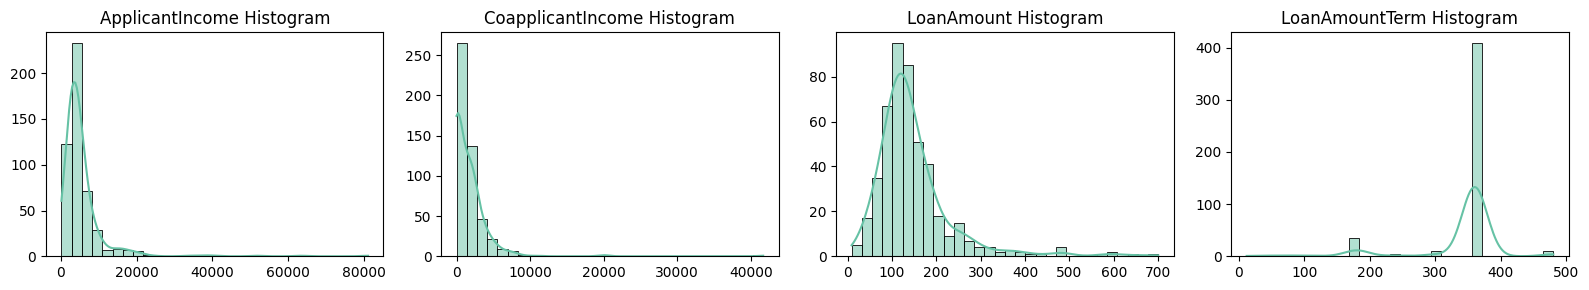

In [33]:
# NUMERICAL VARIABLES(FEATURES) DISTRIBUTION
plot_numerical_distributions(
    df=train_df,
    numerical_columns=NUM_FEATURES,
    cols=4,
    figsize_per_plot=(4, 3)
)

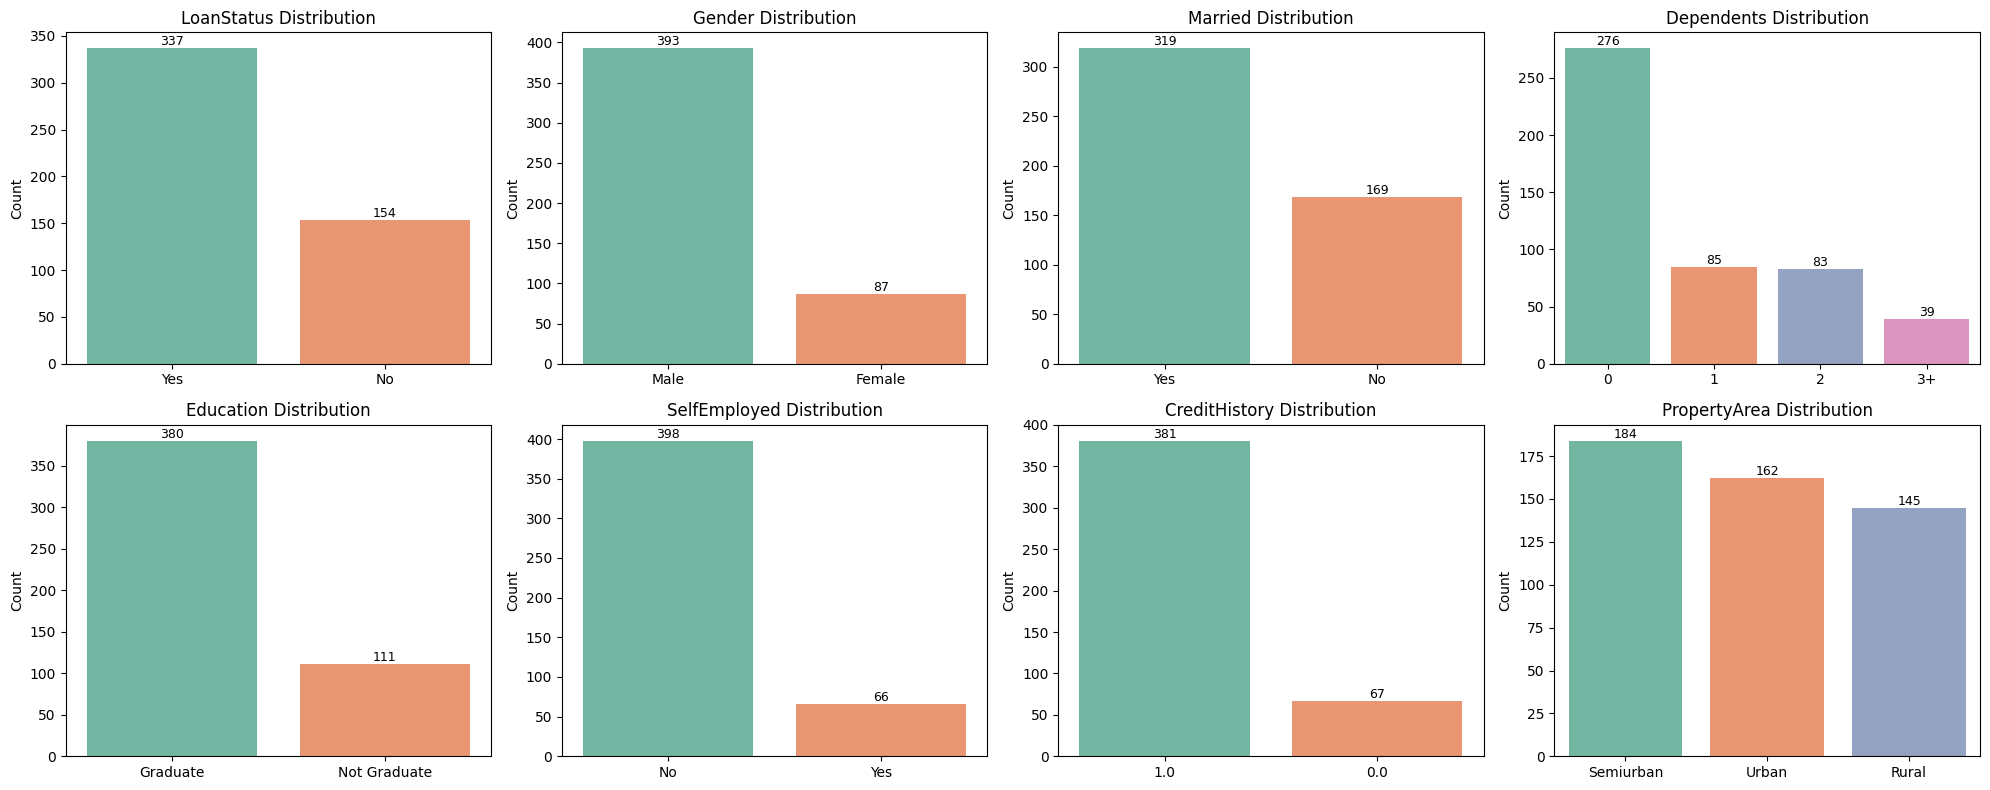

In [34]:
# CATEGORICAL DISTRIBUTIONS
plot_categorical_distributions(
    df=train_df,
    categorical_columns=[LABEL] + CAT_FEATURES,
    cols=4
)

### Bivariate analysis

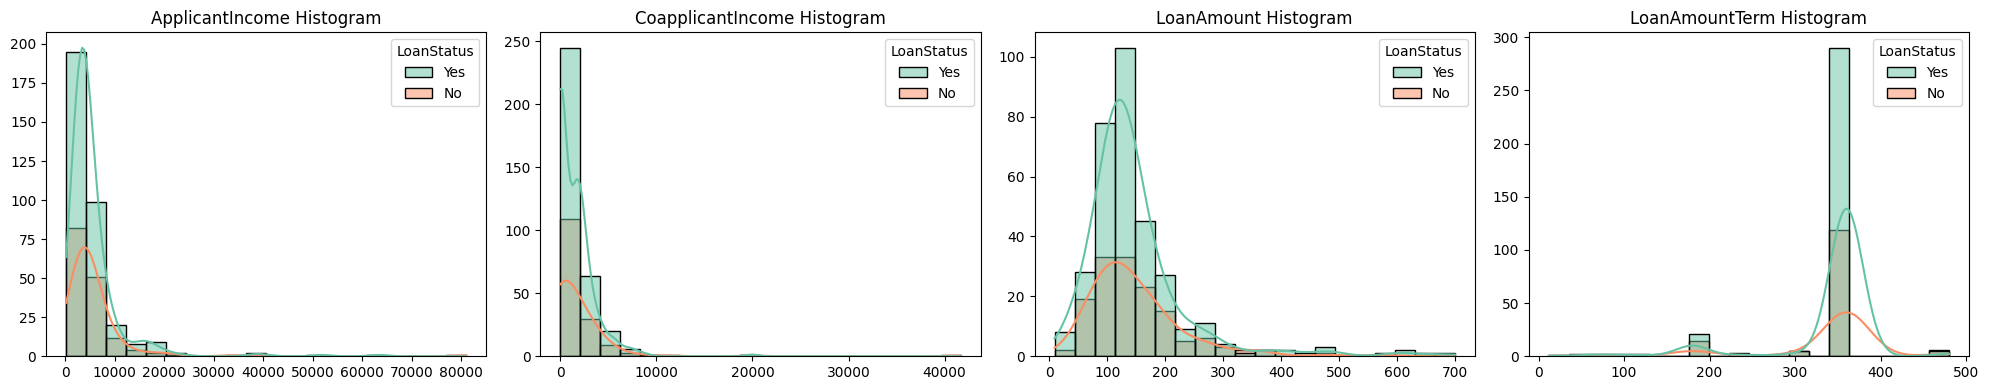

In [35]:
# NUMERICAL FEATURES VS TARGET(CATEGORICAL) DISTRIBUTION
plot_numerical_distributions(
    df=train_df,
    numerical_columns=NUM_FEATURES,
    target_column=LABEL,
    bins=20,
    cols=4
)

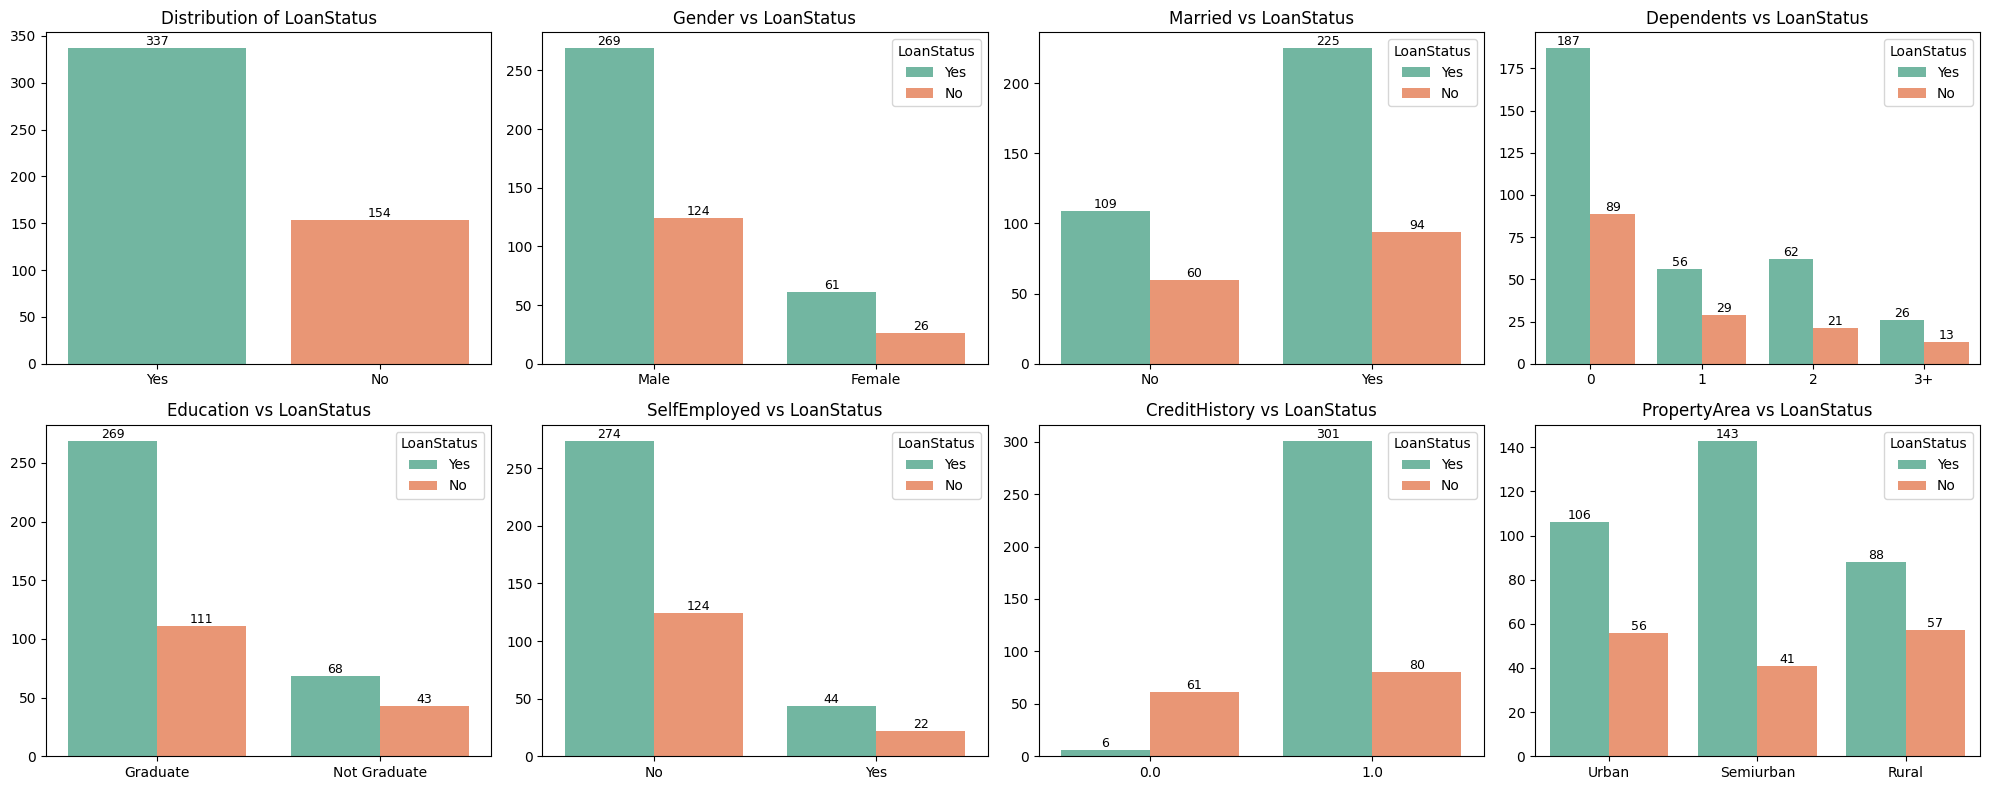

In [36]:
# CATEGORICAL TARGET VS CATEGORICAL FEATURES DISTRIBUTIONS
plot_target_vs_categorical_features(
    df=train_df,
    categorical_columns=CAT_FEATURES,
    target_column="LoanStatus",
    xtick_rotation=0,
    plot_types="bar",
    figsize_per_plot=(5, 4),
    cols=4
)


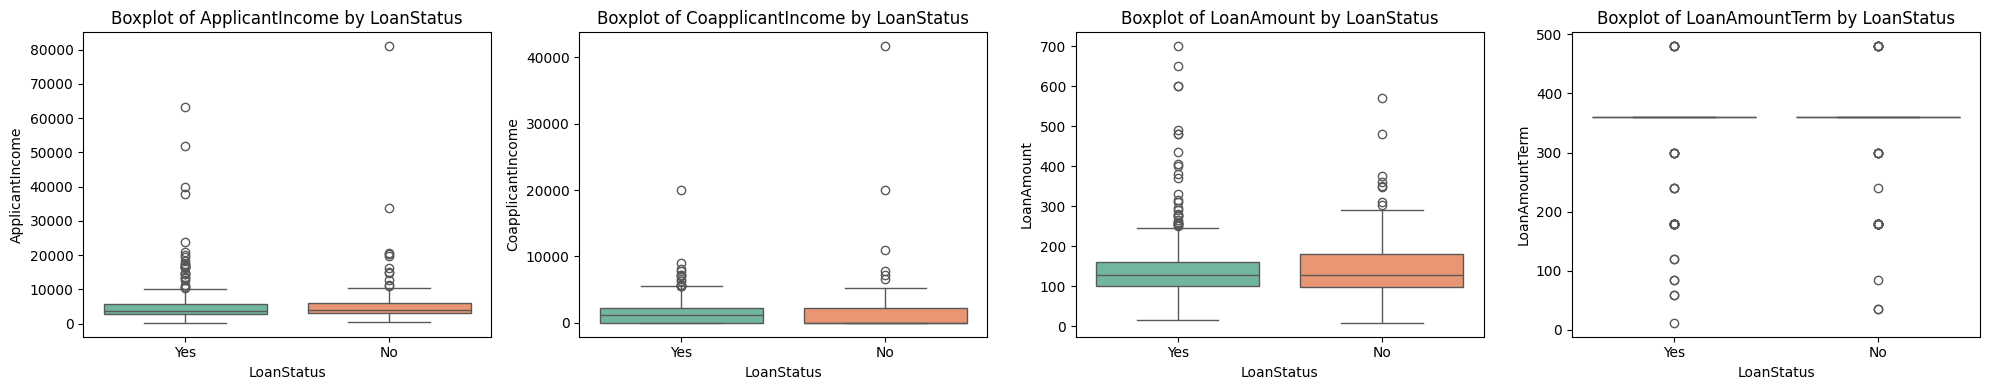

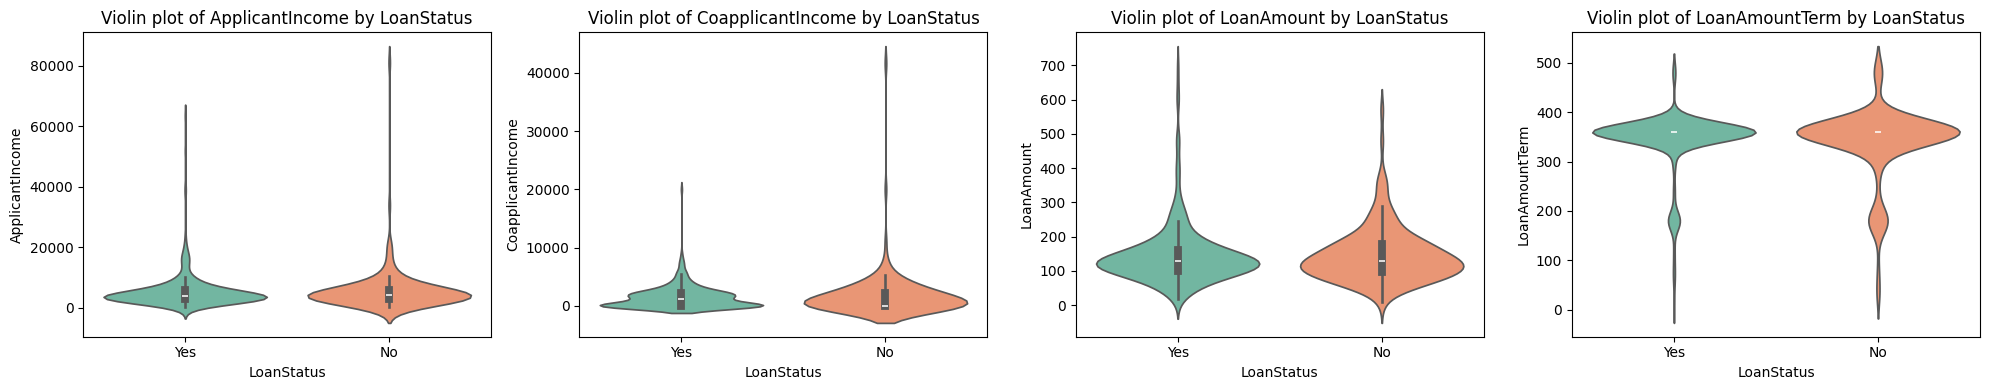

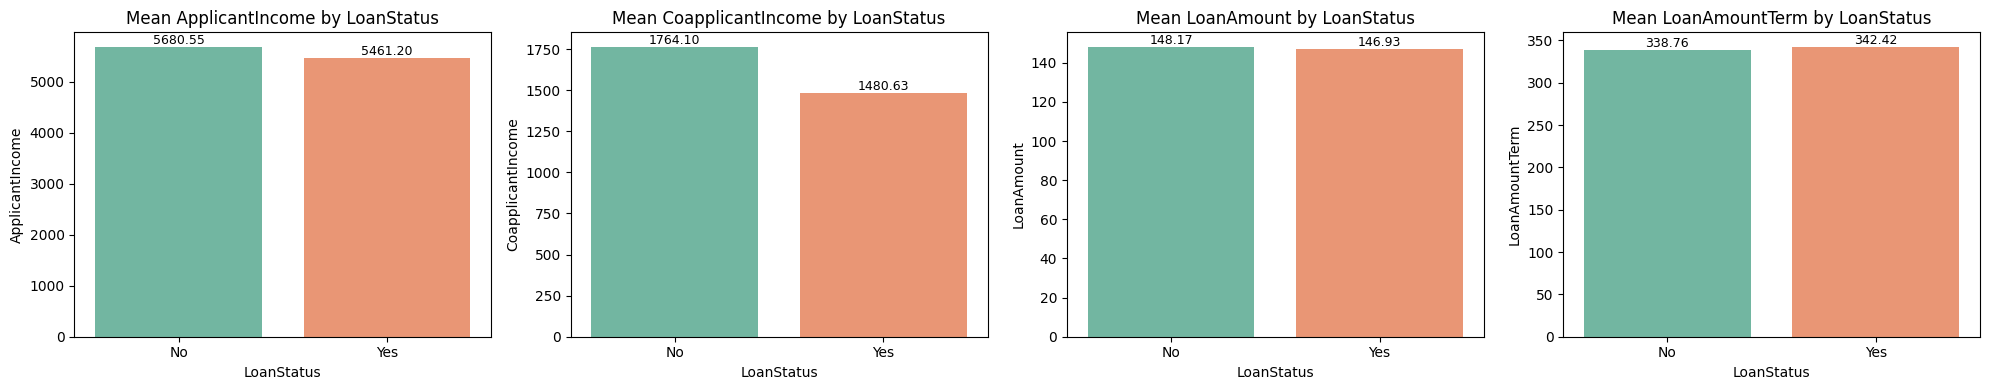

In [37]:
# CATEGORICAL TARGET VS NUMERICAL FEATURES
eda_categorical_vs_numerical(
    df=train_df,
    numerical_columns=NUM_FEATURES,
    label_column="LoanStatus",
    cols=4
)


## Preprocessing

In [38]:
X_train = train_df[FEATURES]
y_train = train_df[LABEL]
y_train = y_train.map(lambda x: 1 if x == "Yes" else 0)

X_test = test_df[FEATURES]
y_test = test_df[LABEL]
y_test = y_test.map(lambda x: 1 if x == "Yes" else 0)

Build preprocessing pipeline

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def get_preprocessor():
    
    numerical_preprocessor_pipeline = Pipeline(
        steps=[
            ("num_imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]
    )

    cat_preprocessor_pipeline = Pipeline(
        steps=[
            ("cat_imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]
    )

    # creating a transformer to combine the two pipelines
    preprocessor = ColumnTransformer([
        ("num_preprocessor", numerical_preprocessor_pipeline, NUM_FEATURES),
        ("cat_preprocessor", cat_preprocessor_pipeline, CAT_FEATURES)
    ])

    return preprocessor


## Cross-validation

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_val_score


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(),
    "KNN": KNeighborsClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [41]:

for name, model in models.items():

    estimator = Pipeline(
        steps=[
            ("preprocessor", get_preprocessor()),
            ("classifier", model)
        ]
    )

    scores = cross_val_score(
        estimator=estimator,
        X=X_train,
        y=y_train,
        cv=5,
        scoring='f1',
    )

    print(f"{name}")
    print(f"Mean F1-Score: {scores.mean():.4f}")
    print("-" * 40)

Logistic Regression
Mean F1-Score: 0.8696
----------------------------------------
Decision Tree
Mean F1-Score: 0.7756
----------------------------------------
Random Forest
Mean F1-Score: 0.8435
----------------------------------------
SVM
Mean F1-Score: 0.8658
----------------------------------------
XGBoost
Mean F1-Score: 0.8200
----------------------------------------
KNN
Mean F1-Score: 0.8309
----------------------------------------
CatBoost
Mean F1-Score: 0.8571
----------------------------------------


## Fine-tune top performing models

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform

import warnings
warnings.filterwarnings("ignore")

### Logistic Regression

In [43]:
# estimator pipeline
estimator = Pipeline(
    steps=[
        ("preprocessor", get_preprocessor()),
        ("classifier", LogisticRegression())
    ]
)

# parameter space
log_reg_params = [
    {
        'classifier__solver': ['liblinear'],
        'classifier__l1_ratio': [0, 1],
        'classifier__C': uniform(0.001, 100),
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000, 2000]
    },
    {
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0, 1],
        'classifier__C': uniform(0.001, 100),
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000, 2000]
    }
]

# instantiate searching algorithm
log_reg_random = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=log_reg_params,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
    refit=True,
)

# search space
log_reg_random.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier__C': <scipy.stats....x7c030fea5990>, 'classifier__class_weight': [None, 'balanced'], 'classifier__l1_ratio': [0, 1], 'classifier__max_iter': [1000, 2000], ...}, {'classifier__C': <scipy.stats....x7c03168cb710>, 'classifier__class_weight': [None, 'balanced'], 'classifier__l1_ratio': [0, 1], 'classifier__max_iter': [1000, 2000], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases,

In [44]:
# best parameters
print("Best Hyperparameters:")
for param_name in log_reg_random.best_params_:
    print(f"{param_name}: {log_reg_random.best_params_[param_name]}")

Best Hyperparameters:
classifier__C: 2.3072425041415756
classifier__class_weight: None
classifier__l1_ratio: 0
classifier__max_iter: 1000
classifier__solver: saga


In [45]:
# best cross-validation score
print(f"Best CV Score: {log_reg_random.best_score_:.4f}")

Best CV Score: 0.8696


### Random Forest

In [46]:
# estimator pipeline
estimator = Pipeline(
    steps=[
        ("preprocessor", get_preprocessor()),
        ("classifier", RandomForestClassifier())
    ]
)

rf_params = {
    'classifier__n_estimators': randint(100, 500),
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 5),
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True, False],
    'classifier__class_weight': [None, 'balanced']
}

# instantiate searching algorithm
rf_random = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=rf_params,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)

# search space
rf_random.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True, False], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [47]:
# best parameters
print("Best Hyperparameters:")
for param_name in rf_random.best_params_:
    print(f"{param_name}: {rf_random.best_params_[param_name]}")

Best Hyperparameters:
classifier__bootstrap: True
classifier__class_weight: None
classifier__max_depth: 20
classifier__max_features: sqrt
classifier__min_samples_leaf: 3
classifier__min_samples_split: 2
classifier__n_estimators: 478


In [48]:
# best cross-validation score
print(f"Best CV F1-Score: {rf_random.best_score_:.4f}")

Best CV F1-Score: 0.8711


### Support Vector Classifier (SVC)

In [49]:

# estimator pipeline
estimator = Pipeline(
    steps=[
        ("preprocessor", get_preprocessor()),
        ("classifier", SVC())
    ]
)

svc_params = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': uniform(0.1, 100),
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': uniform(0.1, 100),
        'classifier__gamma': ['scale', 'auto'],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['poly'],
        'classifier__C': uniform(0.1, 100),
        'classifier__gamma': ['scale', 'auto'],
        'classifier__degree': randint(2, 5),
        'classifier__class_weight': [None, 'balanced']
    }
]

# instantiate searching algorithm
svc_random = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=svc_params,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)

# search space
svc_random.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ier', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier__C': <scipy.stats....x7c02f3115110>, 'classifier__class_weight': [None, 'balanced'], 'classifier__kernel': ['linear']}, {'classifier__C': <scipy.stats....x7c02f3114a10>, 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['rbf']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitte

In [50]:
# best parameters
print("Best Hyperparameters:")
for param_name in svc_random.best_params_:
    print(f"{param_name}: {svc_random.best_params_[param_name]}")

Best Hyperparameters:
classifier__C: 52.577466025838916
classifier__class_weight: None
classifier__kernel: linear


In [51]:
# best cross-validation score
print(f"Best CV F1-Score: {svc_random.best_score_:.4f}")

Best CV F1-Score: 0.8699


### CatBoost

In [52]:
# estimator pipeline
estimator = Pipeline(
    steps=[
        ("preprocessor", get_preprocessor()),
        ("classifier", CatBoostClassifier(verbose=0))
    ]
)


catboost_params = {
    'classifier__iterations': randint(100, 500),
    'classifier__learning_rate': uniform(0.01, 0.2),
    'classifier__depth': randint(4, 10),
    'classifier__l2_leaf_reg': uniform(1, 10)
}

# instantiate searching algorithm
catboost_random = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=catboost_params,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    error_score="raise",
)

# search space
catboost_random.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__depth': <scipy.stats....x7c02f315acd0>, 'classifier__iterations': <scipy.stats....x7c02f3140f50>, 'classifier__l2_leaf_reg': <scipy.stats....x7c02f315a590>, 'classifier__learning_rate': <scipy.stats....x7c0318a6b7d0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across c

In [53]:
# best parameters
print("Best Hyperparameters:")
for param_name in catboost_random.best_params_:
    print(f"{param_name}: {catboost_random.best_params_[param_name]}")

Best Hyperparameters:
classifier__depth: 4
classifier__iterations: 158
classifier__l2_leaf_reg: 4.998609717152554
classifier__learning_rate: 0.019333132642723086


In [54]:
# best cross-validation score
print(f"Best CV F1-Score: {catboost_random.best_score_:.4f}")

Best CV F1-Score: 0.8684


## Threshold Tuning

In [55]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

thresholds = np.arange(0.1, 1.0, 0.05)


### Logistic Regression

Best threshold: 0.30000000000000004
Best F1-score: 0.9081081081081082
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
ROC AUC: 0.7835913312693499


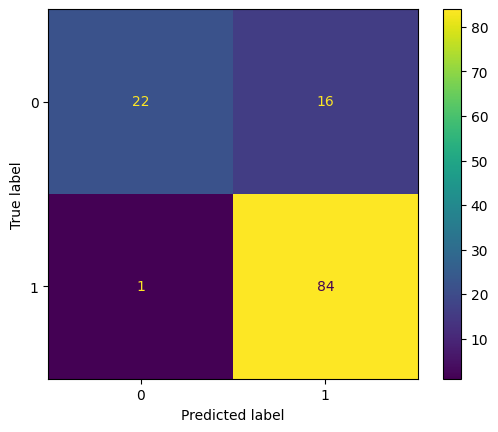

In [56]:

best_threshold = 0
best_f1 = 0

probs = log_reg_random.best_estimator_.predict_proba(X_test)[:, 1]

for threshold in thresholds:

    preds = (probs >= threshold).astype(int)

    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1-score:", best_f1)

y_pred = log_reg_random.predict_proba(X_test)[:, 1]
y_pred = (y_pred >= best_threshold).astype("int")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=log_reg_random.best_estimator_.classes_)
disp.plot()
plt.show()


### Random Forest

Best threshold: 0.40000000000000013
Best F1-score: 0.9032258064516129
Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
ROC AUC: 0.7704334365325077


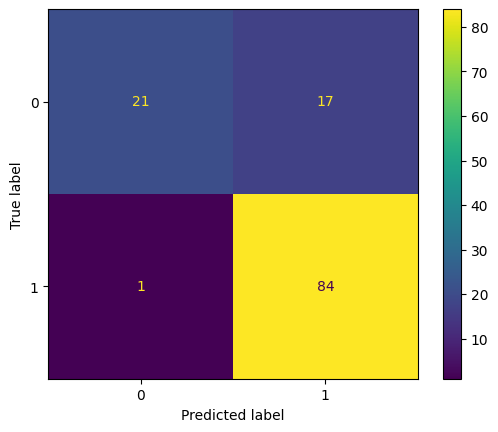

In [57]:

best_threshold = 0
best_f1 = 0

probs = rf_random.best_estimator_.predict_proba(X_test)[:, 1]

for threshold in thresholds:

    preds = (probs >= threshold).astype(int)

    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1-score:", best_f1)

y_pred = catboost_random.predict_proba(X_test)[:, 1]
y_pred = (y_pred >= best_threshold).astype("int")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=rf_random.best_estimator_.classes_)
disp.plot()
plt.show()

### Catboost

Best threshold: 0.6000000000000002
Best F1-score: 0.9130434782608695
Accuracy: 0.8699186991869918
Precision: 0.8484848484848485
Recall: 0.9882352941176471
ROC AUC: 0.796749226006192


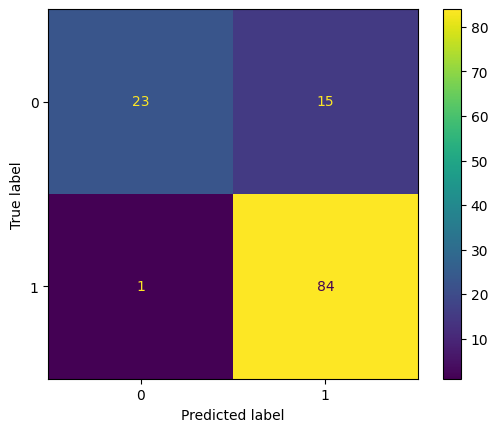

In [58]:

best_threshold = 0
best_f1 = 0

probs = catboost_random.best_estimator_.predict_proba(X_test)[:, 1]

for threshold in thresholds:

    preds = (probs >= threshold).astype(int)

    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1-score:", best_f1)

y_pred = catboost_random.predict_proba(X_test)[:, 1]
y_pred = (y_pred >= best_threshold).astype("int")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=catboost_random.best_estimator_.classes_)
disp.plot()
plt.show()

## Model Choice

chosen model: ```Logistic Regression```
- threshold: 0.35
- f1-score: 0.9081
- accuracy: 0.8537
- Precision: 0.8317
- Recall: 0.9882
<br>
<br>

Reasoning for model choice

- interpretable
- easier deployment
- lower latency
- simpler maintenance

## Production Features

In [61]:
list(X_train.columns)

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'LoanAmountTerm',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'SelfEmployed',
 'CreditHistory',
 'PropertyArea']